<a href="https://colab.research.google.com/github/santhosh-kumar1928/santhoshkumar-codeboosters-2026/blob/main/day2/day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Note on `student_performance.csv`

The previous error indicated that `student_performance.csv` was not found. To ensure the notebook runs smoothly, a dummy `student_performance.csv` has been generated below with a structure similar to what's expected by the subsequent analysis cells. If you have your own `student_performance.csv` file, please upload it to the Colab environment, and the `OioO4Edcdkdd` cell will automatically use your uploaded file.

In [ ]:
import pandas as pd
import numpy as np

# Generate dummy data for student_performance.csv
# This ensures the file exists for subsequent cells to read.
num_students = 30
data = {
    'student_id': range(1001, 1001 + num_students),
    'name': [f'Student_{i}' for i in range(num_students)],
    'age': np.random.randint(18, 22, num_students),
    'gender': np.random.choice(['Male', 'Female'], num_students),
    'department': np.random.choice(['Computer Science', 'Electronics', 'Mechanical', 'Civil'], num_students),
    'semester': np.random.randint(1, 8, num_students),
    'math_score': np.random.randint(50, 100, num_students),
    'science_score': np.random.randint(50, 100, num_students),
    'english_score': np.random.randint(50, 100, num_students),
    'programming_score': np.random.randint(50, 100, num_students),
    'attendance_percentage': np.random.randint(70, 100, num_students),
    'city': np.random.choice(['Mumbai', 'Ahmedabad', 'Delhi', 'Bangalore'], num_students),
    'admission_year': np.random.randint(2020, 2024, num_students)
}
dummy_df = pd.DataFrame(data)
dummy_df.to_csv('student_performance.csv', index=False)
print("Dummy 'student_performance.csv' created.")

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All liblaries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.sqlite_version}")

All liblaries imported successfully!
pandas version: 2.2.2
sqlite3 version: 3.37.2


In [ ]:
df=pd.read_csv('student_performance.csv')
print(f"Dataset loaded:{df.shape[0]}students,{df.shape[1]}columns")
print((f"columns:{df.columns.tolist()}"))
print("\nFirst 3 rows")
df.head(3)

Dataset loaded:30students,13columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
con = sqlite3.connect('college.db')
cursor = con.cursor()
df.to_sql(
    'students',
    con,
    if_exists='replace',
    index=False
    )
cursor.execute("SELECT COUNT(*) FROM students")
count = cursor.fetchone()[0]
print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has {count} rows")

Database 'college.db' created successfully!
Table 'students' has 30 rows


In [ ]:
def run_query(query, description=None):
    if description:
        print(description)
    cursor.execute(query)
    columns = [description[0] for description in cursor.description]
    data = cursor.fetchall()
    return pd.DataFrame(data, columns=columns)

In [ ]:
def run_query(query, query_name="SQL Query"):
    try:
        cursor.execute(query)
        results = cursor.fetchall()
        columns = [description[0] for description in cursor.description]
        df_results = pd.DataFrame(results, columns=columns)
        print(f"\n{query_name}:")
        display(df_results)
        return df_results
    except sqlite3.Error as e:
        print(f"Error executing query '{query_name}': {e}")
        return None

In [ ]:
query1 = """
    SELECT student_id,name,department,math_score, attendance_percentage
    FROM students
    LIMIT 10
"""
result1 = run_query(query1 , "Query 1: First 10 Students (SELECT + LIMIT)")


Query 1: First 10 Students (SELECT + LIMIT):


,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


In [ ]:
query1 = """
    SELECT name,department,math_score
    FROM students
    ORDER BY math_score DESC
    LIMIT 5
"""
result1 = run_query(query1 , "Query 2: Top 5 Math Scores (ORDER BY DESC + LIMIT)")


Query 2: Top 5 Math Scores (ORDER BY DESC + LIMIT):


,name,department,math_score
0,Ananya Das,Computer Science,95
1,Tanvi Mehta,Computer Science,93
2,Arjun Nair,Computer Science,92
3,Akanksha Yadav,Computer Science,91
4,Swati Kulkarni,Computer Science,90


In [ ]:
query1 = """
    SELECT name,math_score,science_score,programming_score,attendance_percentage
    FROM students
    WHERE department = 'Computer Science'
    ORDER BY programming_score DESC
    LIMIT 14
"""
result1 = run_query(query1 , "Query 3: computer science students (ORDER BY DESC + LIMIT)")


Query 3: computer science students (ORDER BY DESC + LIMIT):


,name,math_score,science_score,programming_score,attendance_percentage
0,Ananya Das,95,89,97,98
1,Tanvi Mehta,93,90,96,97
2,Arjun Nair,92,88,95,90
3,Akanksha Yadav,91,93,94,95
4,Divya Singh,88,91,93,96
5,Swati Kulkarni,90,87,92,94
6,Aarav Sharma,85,78,91,92
7,Amit Bose,86,82,89,91
8,Suresh Rao,83,86,88,88
9,Gaurav Shukla,84,79,87,87


In [ ]:
query4 = """
SELECT name,department,attendance_percentage
    FROM students
    WHERE attendance_percentage>90 AND department != 'Civil'
    ORDER BY attendance_percentage DESC
"""
result4= run_query(query4 , "Query 4: attendance_percentage (>90%)exclude civil (ORDER BY DESC)")


Query 4: attendance_percentage (>90%)exclude civil (ORDER BY DESC):


,name,department,attendance_percentage
0,Ananya Das,Computer Science,98
1,Tanvi Mehta,Computer Science,97
2,Divya Singh,Computer Science,96
3,Sneha Reddy,Mechanical,95
4,Akanksha Yadav,Computer Science,95
5,Swati Kulkarni,Computer Science,94
6,Ritu Agarwal,Electronics,93
7,Aarav Sharma,Computer Science,92
8,Kavya Nambiar,Mechanical,91
9,Amit Bose,Computer Science,91


In [ ]:
query5 = """
SELECT name,department,attendance_percentage
    FROM students
    WHERE attendance_percentage>93 AND department != 'Mechanical'
    ORDER BY attendance_percentage DESC
    LIMIT 5
"""
result5= run_query(query5 , "Query 5: attendance_percentage (>93%)exclude mechanical (ORDER BY DESC)")


Query 5: attendance_percentage (>93%)exclude mechanical (ORDER BY DESC):


,name,department,attendance_percentage
0,Ananya Das,Computer Science,98
1,Tanvi Mehta,Computer Science,97
2,Divya Singh,Computer Science,96
3,Akanksha Yadav,Computer Science,95
4,Swati Kulkarni,Computer Science,94


In [ ]:
query5 = """
SELECT
    department,
    COUNT(*)  AS num_student,
    ROUND(AVG(math_score),2) AS avg_math_score,
    ROUND(AVG(science_score),2) AS avg_science_score,
    ROUND(AVG(programming_score),2) AS avg_programming_score,
    ROUND(AVG(attendance_percentage),2) AS avg_attendance

FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
result5= run_query(query5 , "Query 5: Department-wise (ORDER BY DESC)")


Query 5: Department-wise (ORDER BY DESC):


,department,num_student,avg_math_score,avg_science_score,avg_programming_score,avg_attendance
0,Computer Science,13,85.62,84.46,89.23,90.69
1,Mechanical,6,71.00,76.50,49.33,83.50
2,Electronics,6,71.00,74.17,61.50,80.33
3,Civil,5,63.40,66.60,40.60,74.60


In [ ]:
query6="""
SELECT
     department,
     ROUND(AVG(math_score),2) AS avg_math_score,
     COUNT(*) AS students
     FROM students
     GROUP BY department
     HAVING AVG(math_score)>70
     ORDER BY students DESC
"""
result6= run_query(query6 , "Query 6: Department with Avg Math>70 (HAVING)")


Query 6: Department with Avg Math>70 (HAVING):


,department,avg_math_score,students
0,Computer Science,85.62,13
1,Mechanical,71.00,6
2,Electronics,71.00,6


In [ ]:
query5 = """
SELECT
    gender,
    COUNT(*)  AS num_student,
    ROUND(AVG(math_score),2) AS avg_math_score,
    ROUND(AVG(science_score),2) AS avg_science_score,
    ROUND(AVG(programming_score),2) AS avg_programming_score,
    ROUND(AVG(attendance_percentage),2) AS avg_attendance

FROM students
GROUP BY gender
"""
result5= run_query(query5 , "Query 5: gender-wise Perfomance(ORDER BY DESC)")


Query 5: gender-wise Perfomance(ORDER BY DESC):


,gender,num_student,avg_math_score,avg_science_score,avg_programming_score,avg_attendance
0,Female,15,78.47,81.20,70.2,88.53
1,Male,15,73.67,74.47,65.0,80.47


'student_performance.csv' not found. Generating dummy data.
Dummy 'student_performance.csv' created.
Table 'students' ensured in college.db


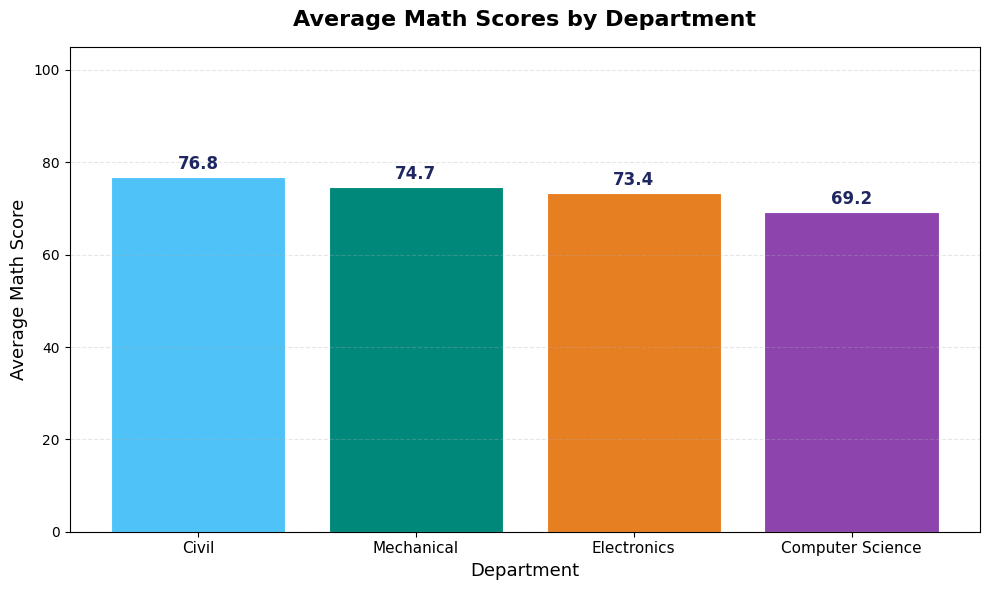

In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Import numpy for dummy data generation
import os # Import os to check for file existence

conn = sqlite3.connect('college.db')

# Ensure 'student_performance.csv' exists and 'df' is loaded
csv_file_path = 'student_performance.csv'

if not os.path.exists(csv_file_path):
    print(f"'{csv_file_path}' not found. Generating dummy data.")
    # Generate dummy data for student_performance.csv
    num_students = 30
    data = {
        'student_id': range(1001, 1001 + num_students),
        'name': [f'Student_{i}' for i in range(num_students)],
        'age': np.random.randint(18, 22, num_students),
        'gender': np.random.choice(['Male', 'Female'], num_students),
        'department': np.random.choice(['Computer Science', 'Electronics', 'Mechanical', 'Civil'], num_students),
        'semester': np.random.randint(1, 8, num_students),
        'math_score': np.random.randint(50, 100, num_students),
        'science_score': np.random.randint(50, 100, num_students),
        'english_score': np.random.randint(50, 100, num_students),
        'programming_score': np.random.randint(50, 100, num_students),
        'attendance_percentage': np.random.randint(70, 100, num_students),
        'city': np.random.choice(['Mumbai', 'Ahmedabad', 'Delhi', 'Bangalore'], num_students),
        'admission_year': np.random.randint(2020, 2024, num_students)
    }
    df = pd.DataFrame(data)
    df.to_csv(csv_file_path, index=False)
    print(f"Dummy '{csv_file_path}' created.")
else:
    print(f"'{csv_file_path}' found. Loading existing data.")
    df = pd.read_csv(csv_file_path)

# Ensure the 'students' table exists for this connection
df.to_sql('students', conn, if_exists='replace', index=False)
print("Table 'students' ensured in college.db")

#Get data using SQL
chart1_sql = """
SELECT department, ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


#Create thr bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_color = ['#4FC3F7','#00897B','#E67E22','#8E44AD']

bars = ax.bar(chart1_data['department'], chart1_data['avg_math'], color=bar_color, edgecolor = 'white', linewidth = 0.8)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight = 'bold',
        color='#1E2761'
    )

ax.set_title('Average Math Scores by Department', fontsize=16, fontweight='bold', pad = 15)
ax.set_xlabel('Department', fontsize = 13)
ax.set_ylabel('Average Math Score', fontsize = 13)
ax.set_ylim(0,105)
ax.tick_params(axis='x', labelsize = 11)
ax.grid(axis='y', alpha = 0.3, linestyle ='--')

plt.tight_layout()
plt.show()

'student_performance.csv' found. Loading existing data.
Table 'students' ensured in college.db


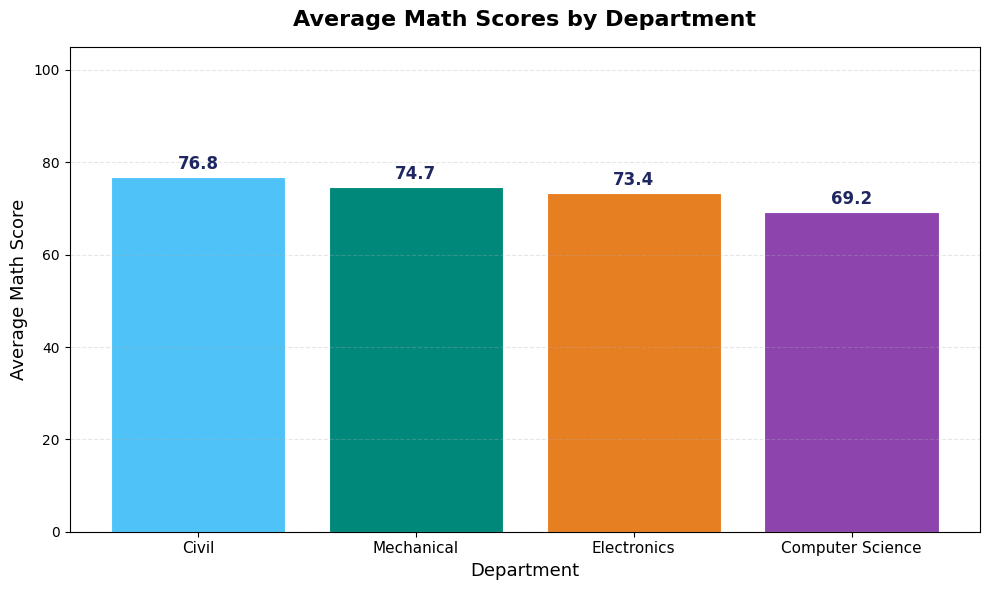

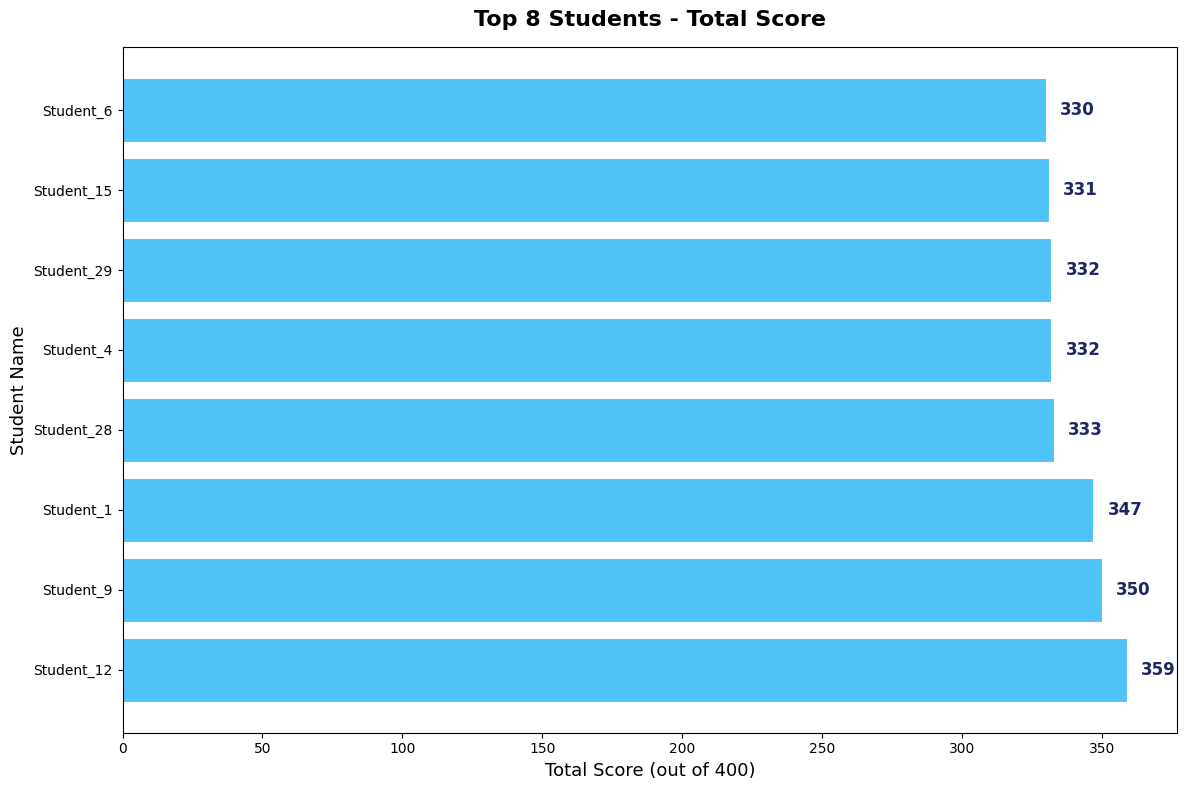

In [33]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('college.db')

# Get data using SQL for top 8 students by total score
chart1_sql = """
SELECT name, (math_score + science_score + english_score +programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


# Create the bar chart
fig, ax = plt.subplots(figsize=(12, 8))

bar_color = ['#4FC3F7']

bars = ax.barh(chart1_data['name'], chart1_data['total_score'], color=bar_color, edgecolor = 'white', linewidth = 0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5, # Adjust position for text
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}', # Display as integer
        ha='left',
        va='center',
        fontsize=12,
        fontweight = 'bold',
        color='#1E2761'
    )

ax.set_title('Top 8 Students - Total Score', fontsize=16, fontweight='bold', pad = 15)
ax.set_ylabel('Student Name', fontsize = 13)
ax.set_xlabel('Total Score (out of 400)', fontsize = 13)
plt.tight_layout()
plt.show()